In [ ]:
!pip install -q datasets pillow tqdm

from google.colab import drive
drive.mount('/content/drive')

import json, re, random, zipfile, shutil
from pathlib import Path
from collections import defaultdict, Counter
from tqdm.auto import tqdm
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ── Keliai ───────────────────────────────────────────────────────────────────
DRIVE_ROOT  = Path('/content/drive/MyDrive/VU_DL_Team_Project')
LOCAL_TMP   = Path('/content/pii_tmp')
OUT_DIR     = DRIVE_ROOT / 'data' / 'pii_v1'
IMG_DIR     = LOCAL_TMP / 'images'

# ── Konstantos ────────────────────────────────────────────────────────────────
RANDOM_SEED       = 42
SPLIT_RATIO       = (0.80, 0.10, 0.10)
NEGATIVE_FRACTION = 0.15    # ~15% galutinio dataseto bus tuščių ekranų
MIN_BBOX_PX       = 4       # mažesni bbox'ai ignoruojami
MAX_NEG_SAVE      = 3_000   # kiek negative kandidatų išsaugom į diską iš anksto

PHASE1_LABELS = {
    'email_address', 'phone_number', 'full_name',
    'username', 'account_balance', 'transaction_amount'
}

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

for d in [LOCAL_TMP, IMG_DIR, OUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('Directories ready.')


Mounted at /content/drive
Directories ready.


In [ ]:
import re

# ─────────────────────────────────────────────────────────────────────────────
# §1. PII FILTRAVIMO TAISYKLĖS
# ─────────────────────────────────────────────────────────────────────────────

KEYWORD_MAP = [
    # Phase 1 (prioritetiniai)
    (re.compile(r'\bemail\b', re.I),                                        'email_address'),
    (re.compile(r'\bphone\b|\bmobile\b|\bcall\b', re.I),                    'phone_number'),
    (re.compile(r'\bbalance\b|\bnet worth\b', re.I),                        'account_balance'),
    (re.compile(r'\btransaction\b|\bpayment\b|\bcharge\b|\bpurchase\b|'
                r'\btotal\b.{0,20}\b(amount|price|cost|paid|due)\b', re.I), 'transaction_amount'),
    (re.compile(r'\b(first|last|full|display)\s*(name|names)\b|'
                r'\bname\s+of\s+(user|person|account)\b', re.I),            'full_name'),
    (re.compile(r'\busername\b|\buser\s*id\b|\blogin\s*name\b', re.I),      'username'),
    # Phase 2
    (re.compile(r'\baccount\s*(number|no|#)\b|\bcard\s*(number|no|#)\b', re.I), 'account_number'),
    (re.compile(r'\baddress\b|\bstreet\b|\bzip\b|\bpostal\b', re.I),       'address'),
    (re.compile(r'\b(date\s+of\s+birth|dob|birthday|born)\b', re.I),       'date_of_birth'),
    (re.compile(r'\bssn\b|\bsocial\s+security\b|\bpassport\b', re.I),      'id_number'),
]

def classify_question(question):
    for pattern, label in KEYWORD_MAP:
        if pattern.search(question or ''):
            return label
    return None

def validate_bbox(bbox, img_w=99999, img_h=99999):
    """SCHEMA §3: XYXY, int, min 4px."""
    if not isinstance(bbox, (list, tuple)) or len(bbox) != 4:
        return None
    try:
        x1, y1, x2, y2 = [int(round(float(v))) for v in bbox]
    except Exception:
        return None
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(img_w, x2), min(img_h, y2)
    if x2 - x1 < MIN_BBOX_PX or y2 - y1 < MIN_BBOX_PX or x1 >= x2 or y1 >= y2:
        return None
    return [x1, y1, x2, y2]

# Sanity check
tests = [
    ('What is the email address shown?',  'email_address'),
    ('What phone number is displayed?',   'phone_number'),
    ('What is the total balance?',        'account_balance'),
    ('How much was the last payment?',    'transaction_amount'),
    ("What is the user's last name?",     'full_name'),
    ('What username is shown?',           'username'),
    ('What color is the button?',         None),
    ('How many apps are listed?',         None),
]
ok = True
for q, exp in tests:
    got = classify_question(q)
    if got != exp:
        ok = False
    print(f'{"OK" if got==exp else "!!"} {q[:50]:<52s} -> {str(got)}')
print('Visi testai OK!' if ok else 'WARN: patikrink KEYWORD_MAP!')

OK What is the email address shown?                     -> email_address
OK What phone number is displayed?                      -> phone_number
OK What is the total balance?                           -> account_balance
OK How much was the last payment?                       -> transaction_amount
OK What is the user's last name?                        -> full_name
OK What username is shown?                              -> username
OK What color is the button?                            -> None
OK How many apps are listed?                            -> None
Visi testai OK!


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# §2. PAGRINDINIS LOOP — vienas perėjimas per visą datasetą
# ─────────────────────────────────────────────────────────────────────────────

from datasets import load_dataset
from collections import Counter
from tqdm.auto import tqdm
from pathlib import Path

# Užtikrinam, kad konstantos yra pasiekiamos (jei pirma celė nebuvo paleista)
MAX_NEG_SAVE = 3_000
MIN_BBOX_PX = 4

print('\nKraunam RICO-ScreenQA stream...')
ds_stream = load_dataset(
    'rootsautomation/RICO-ScreenQA',
    split='train',
    streaming=True,
)

# screen_data[screen_id] = {
#   'objects': [...],          # PII objektai
#   'image_width': int,
#   'image_height': int,
# }
screen_data    = {}
neg_candidates = {}   # screen_id → {image_width, image_height} — potencialūs negative'ai
matched_qa     = 0
skipped_qa     = 0
img_errors     = 0
label_counter  = Counter()

# EDA stats (kaupiami inline)
eda_all_questions   = []
eda_bbox_per_qa     = []
eda_widths          = []
eda_heights         = []

for idx, row in enumerate(tqdm(ds_stream, desc='Processing RICO-ScreenQA')):
    screen_id = str(row['screen_id'])
    question  = row['question']
    img       = row['image']
    w, h      = img.width, img.height

    # EDA: renkam visų klausimų žodžius
    eda_all_questions.append(question)
    n_bboxes = sum(
        len(gt.get('ui_elements', []))
        for gt in row.get('ground_truth', [])
    )
    eda_bbox_per_qa.append(n_bboxes)

    label = classify_question(question)

    # ── PII match ──────────────────────────────────────────────────────────
    if label:
        seen = set()
        new_objs = []
        for gt in row.get('ground_truth', []):
            ans = gt.get('full_answer', '')
            for elem in gt.get('ui_elements', []):
                bbox = validate_bbox(elem.get('bounds'), w, h)
                if bbox is None:
                    continue
                key = tuple(bbox)
                if key in seen:
                    continue
                seen.add(key)
                new_objs.append({
                    'bbox':            bbox,
                    'label':           label,
                    'source_question': question,
                    'source_answer':   ans,
                })

        if new_objs:
            # Pirmas kartas matom šį screen → išsaugom image
            if screen_id not in screen_data:
                img_path = IMG_DIR / f'{screen_id}.png'
                try:
                    img.save(img_path, format='PNG')
                    screen_data[screen_id] = {
                        'objects':      [],
                        'image_width':  w,
                        'image_height': h,
                    }
                    eda_widths.append(w)
                    eda_heights.append(h)
                    # Jei buvo negative candidate — pašalinam
                    neg_candidates.pop(screen_id, None)
                except Exception:
                    img_errors += 1
                    img.close()
                    skipped_qa += 1
                    continue

            screen_data[screen_id]['objects'].extend(new_objs)
            label_counter[label] += len(new_objs)
            matched_qa += 1
            img.close()
            continue

    # ── Negative kandidatas ────────────────────────────────────────────────
    if (screen_id not in screen_data and
        screen_id not in neg_candidates and
        len(neg_candidates) < MAX_NEG_SAVE):
        img_path = IMG_DIR / f'{screen_id}.png'
        try:
            img.save(img_path, format='PNG')
            neg_candidates[screen_id] = {'image_width': w, 'image_height': h}
        except Exception:
            img_errors += 1

    img.close()
    skipped_qa += 1

# ── Deduplikuojam objektus per screen ─────────────────────────────────────────
for sid in screen_data:
    seen = set()
    unique = []
    for obj in screen_data[sid]['objects']:
        key = (tuple(obj['bbox']), obj['label'])
        if key not in seen:
            seen.add(key)
            unique.append(obj)
    screen_data[sid]['objects'] = unique

# ── Pašalinam PII screens iš negative pool ────────────────────────────────────
neg_candidates = {
    sid: meta for sid, meta in neg_candidates.items()
    if sid not in screen_data
}

pii_screen_ids = list(screen_data.keys())

print(f'\nMatched QA    : {matched_qa:,}')
print(f'Skipped QA    : {skipped_qa:,}')
print(f'PII ekranai   : {len(pii_screen_ids):,}')
print(f'Neg candidates: {len(neg_candidates):,}')
print(f'Image klaidos : {img_errors}')
print()
for l, c in sorted(label_counter.items(), key=lambda x: -x[1]):
    print(f'  {"P1" if l in PHASE1_LABELS else "P2"}  {l:<25s}: {c:5d}')


Kraunam RICO-ScreenQA stream...



Matched QA    : 3,781
Skipped QA    : 65,199
PII ekranai   : 3,099
Neg candidates: 3,000
Image klaidos : 0

  P1  email_address            :  1490
  P1  phone_number             :   649
  P2  address                  :   605
  P1  username                 :   493
  P1  transaction_amount       :   273
  P2  date_of_birth            :   262
  P1  full_name                :   184
  P1  account_balance          :   131
  P2  account_number           :    10
  P2  id_number                :     2


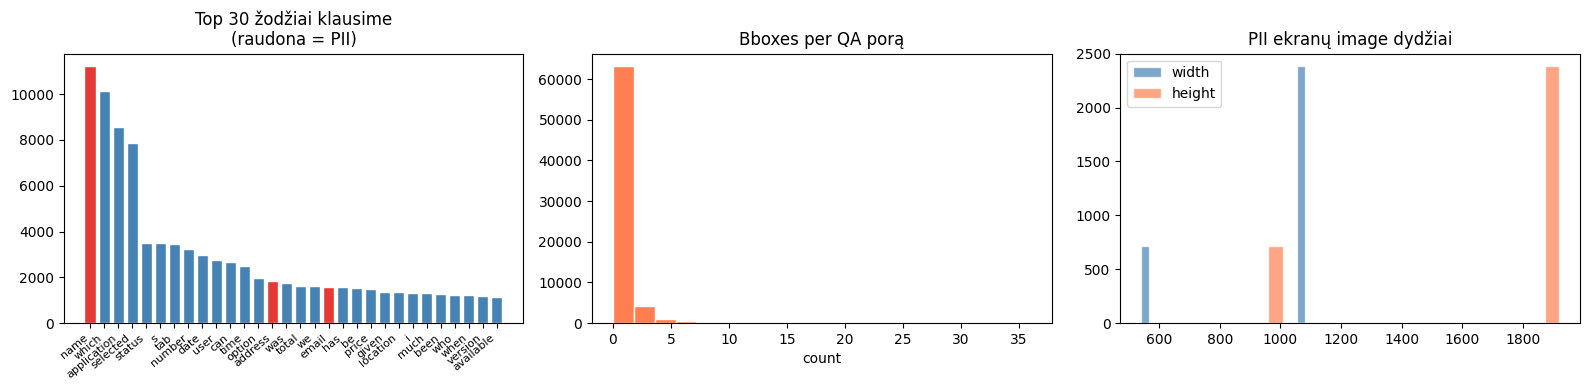

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# §3. EDA — Raw statistics
# ─────────────────────────────────────────────────────────────────────────────

# Word frequency in questions (helps verify KEYWORD_MAP coverage)
STOP = {"what","is","the","a","an","in","on","of","to","and","or","are",
        "how","many","does","do","this","that","shown","displayed","app",
        "screen","image","button","text","icon","there","for","at","with"}
word_freq = Counter()
for q in eda_all_questions:
    word_freq.update(
        w for w in re.findall(r"\w+", q.lower())
        if w not in STOP
    )
top30 = word_freq.most_common(30)
PII_KW = {"email","phone","name","balance","account","address",
          "username","transaction","payment"}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Top 30 words — red = PII-related
words, counts = zip(*top30)
bar_colors = ["#E53935" if w in PII_KW else "steelblue" for w in words]
axes[0].bar(words, counts, color=bar_colors, edgecolor="white")
axes[0].set_title("Top 30 words in questions
(red = PII-related)")
plt.setp(axes[0].get_xticklabels(), rotation=40, ha="right", fontsize=8)

# Bboxes per QA pair
axes[1].hist(eda_bbox_per_qa, bins=20, color="coral", edgecolor="white")
axes[1].set_title("Bboxes per QA pair")
axes[1].set_xlabel("count")

# Image dimensions of PII screens
axes[2].hist(eda_widths, bins=20, color="steelblue", edgecolor="white",
             alpha=0.7, label="width")
axes[2].hist(eda_heights, bins=20, color="coral", edgecolor="white",
             alpha=0.7, label="height")
axes[2].set_title("PII screen image dimensions")
axes[2].legend()

plt.tight_layout()
plt.savefig(LOCAL_TMP / "eda_raw.png", dpi=120)
plt.show()


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# §4. NEGATIVE EXAMPLES + FINAL ENTRIES
# ─────────────────────────────────────────────────────────────────────────────

# Calculate how many negatives needed to reach ~15% of total dataset
n_pos = len(pii_screen_ids)
n_neg = int(n_pos * NEGATIVE_FRACTION / (1 - NEGATIVE_FRACTION))
n_neg = min(n_neg, len(neg_candidates))

neg_sids = random.sample(list(neg_candidates.keys()), n_neg)

# Build positive entries — re-validate bboxes with exact image dimensions
positive_entries = []
for sid in pii_screen_ids:
    d = screen_data[sid]
    valid_objs = []
    for obj in d["objects"]:
        bbox = validate_bbox(obj["bbox"], d["image_width"], d["image_height"])
        if bbox:
            valid_objs.append({**obj, "bbox": bbox})
    if valid_objs:
        positive_entries.append({
            "image":        f"images/{sid}.png",
            "image_width":  d["image_width"],
            "image_height": d["image_height"],
            "screen_id":    sid,
            "objects":      valid_objs,
        })

# Build negative entries — screens with no PII (objects=[])
negative_entries = [
    {
        "image":        f"images/{sid}.png",
        "image_width":  neg_candidates[sid]["image_width"],
        "image_height": neg_candidates[sid]["image_height"],
        "screen_id":    sid,
        "objects":      [],
    }
    for sid in neg_sids
]

final_entries = positive_entries + negative_entries
random.shuffle(final_entries)

total   = len(final_entries)
n_empty = len(negative_entries)
print(f"Positive : {len(positive_entries):,}")
print(f"Negative : {n_empty:,} ({n_empty/total*100:.1f}%)")
print(f"Total    : {total:,}")


NameError: name 'pii_screen_ids' is not defined

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# §5. TRAIN / VAL / TEST SPLIT
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.model_selection import train_test_split

all_ids   = [e["screen_id"] for e in final_entries]
entry_map = {e["screen_id"]: e for e in final_entries}

# Split by screen_id (not by row) to prevent leakage — SCHEMA §5
val_test  = SPLIT_RATIO[1] + SPLIT_RATIO[2]
train_ids, temp    = train_test_split(all_ids, test_size=val_test,
                                       random_state=RANDOM_SEED)
val_ids, test_ids  = train_test_split(temp, test_size=0.5,
                                       random_state=RANDOM_SEED)

train_entries = [entry_map[s] for s in train_ids]
val_entries   = [entry_map[s] for s in val_ids]
test_entries  = [entry_map[s] for s in test_ids]

# Verify no screen_id leakage between splits
assert not (set(train_ids) & set(val_ids)),  "LEAKAGE train/val!"
assert not (set(train_ids) & set(test_ids)), "LEAKAGE train/test!"
assert not (set(val_ids)   & set(test_ids)), "LEAKAGE val/test!"

print(f"Train : {len(train_entries):,}")
print(f"Val   : {len(val_entries):,}")
print(f"Test  : {len(test_entries):,}")
print("No leakage OK")


Train : 2,916
Val   : 364
Test  : 365
No leakage OK


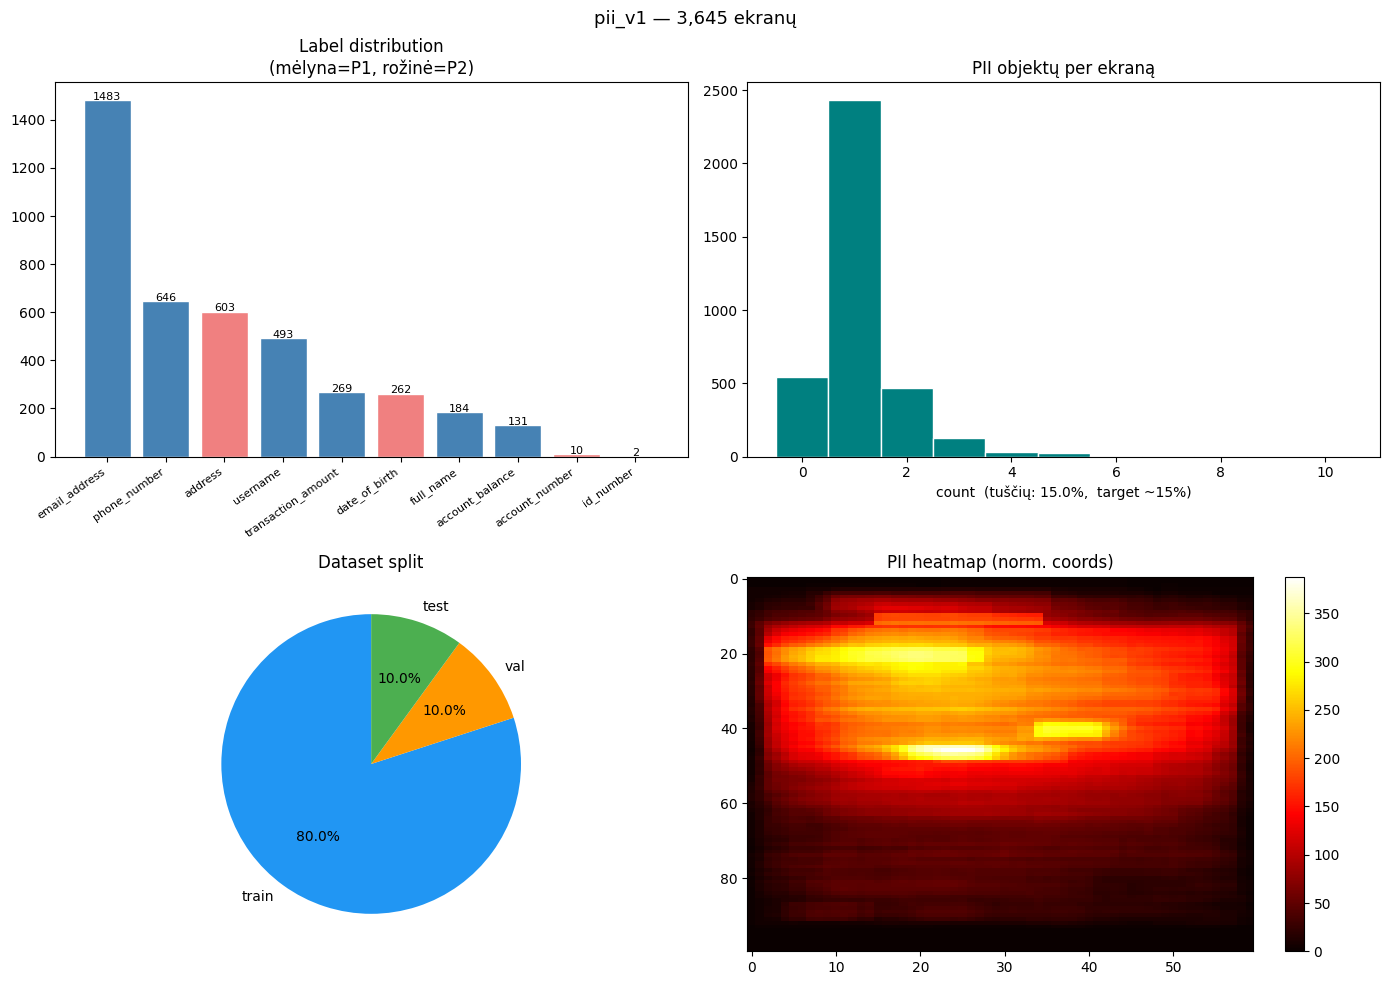

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# §6. EDA — Final dataset
# ─────────────────────────────────────────────────────────────────────────────

all_labels = [obj["label"] for e in final_entries for obj in e["objects"]]
lc  = Counter(all_labels)
opc = [len(e["objects"]) for e in final_entries]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Label distribution — blue = Phase 1, red = Phase 2
ls = sorted(lc.keys(), key=lambda k: -lc[k])
cl = ["steelblue" if l in PHASE1_LABELS else "lightcoral" for l in ls]
axes[0, 0].bar(ls, [lc[l] for l in ls], color=cl, edgecolor="white")
axes[0, 0].set_title("Label distribution
(blue=Phase1, red=Phase2)")
plt.setp(axes[0, 0].get_xticklabels(), rotation=35, ha="right", fontsize=8)
for i, (l, c) in enumerate(zip(ls, [lc[x] for x in ls])):
    axes[0, 0].text(i, c + 0.5, str(c), ha="center", fontsize=8)

# PII objects per screen
axes[0, 1].hist(opc, bins=range(0, max(opc) + 2), color="teal",
                edgecolor="white", align="left")
pct_empty = opc.count(0) / len(opc) * 100
axes[0, 1].set_title("PII objects per screen")
axes[0, 1].set_xlabel(f"count  (empty: {pct_empty:.1f}%,  target ~15%)")

# Dataset split proportions
axes[1, 0].pie(
    [len(train_entries), len(val_entries), len(test_entries)],
    labels=["train", "val", "test"],
    autopct="%1.1f%%",
    colors=["#2196F3", "#FF9800", "#4CAF50"],
    startangle=90
)
axes[1, 0].set_title("Dataset split")

# Bbox position heatmap — where PII tends to appear on screen
HW, HH = 60, 100
hm = np.zeros((HH, HW))
for e in final_entries:
    iw, ih = e["image_width"], e["image_height"]
    for obj in e["objects"]:
        x1, y1, x2, y2 = obj["bbox"]
        gx1 = int(x1 / iw * HW)
        gx2 = min(int(x2 / iw * HW), HW - 1)
        gy1 = int(y1 / ih * HH)
        gy2 = min(int(y2 / ih * HH), HH - 1)
        hm[gy1:gy2 + 1, gx1:gx2 + 1] += 1
im = axes[1, 1].imshow(hm, cmap="hot", origin="upper", aspect="auto")
plt.colorbar(im, ax=axes[1, 1])
axes[1, 1].set_title("PII heatmap (normalised screen coords)")

plt.suptitle(f"pii_v1 — {len(final_entries):,} screens", fontsize=13)
plt.tight_layout()
plt.savefig(LOCAL_TMP / "eda_final.png", dpi=120)
plt.show()


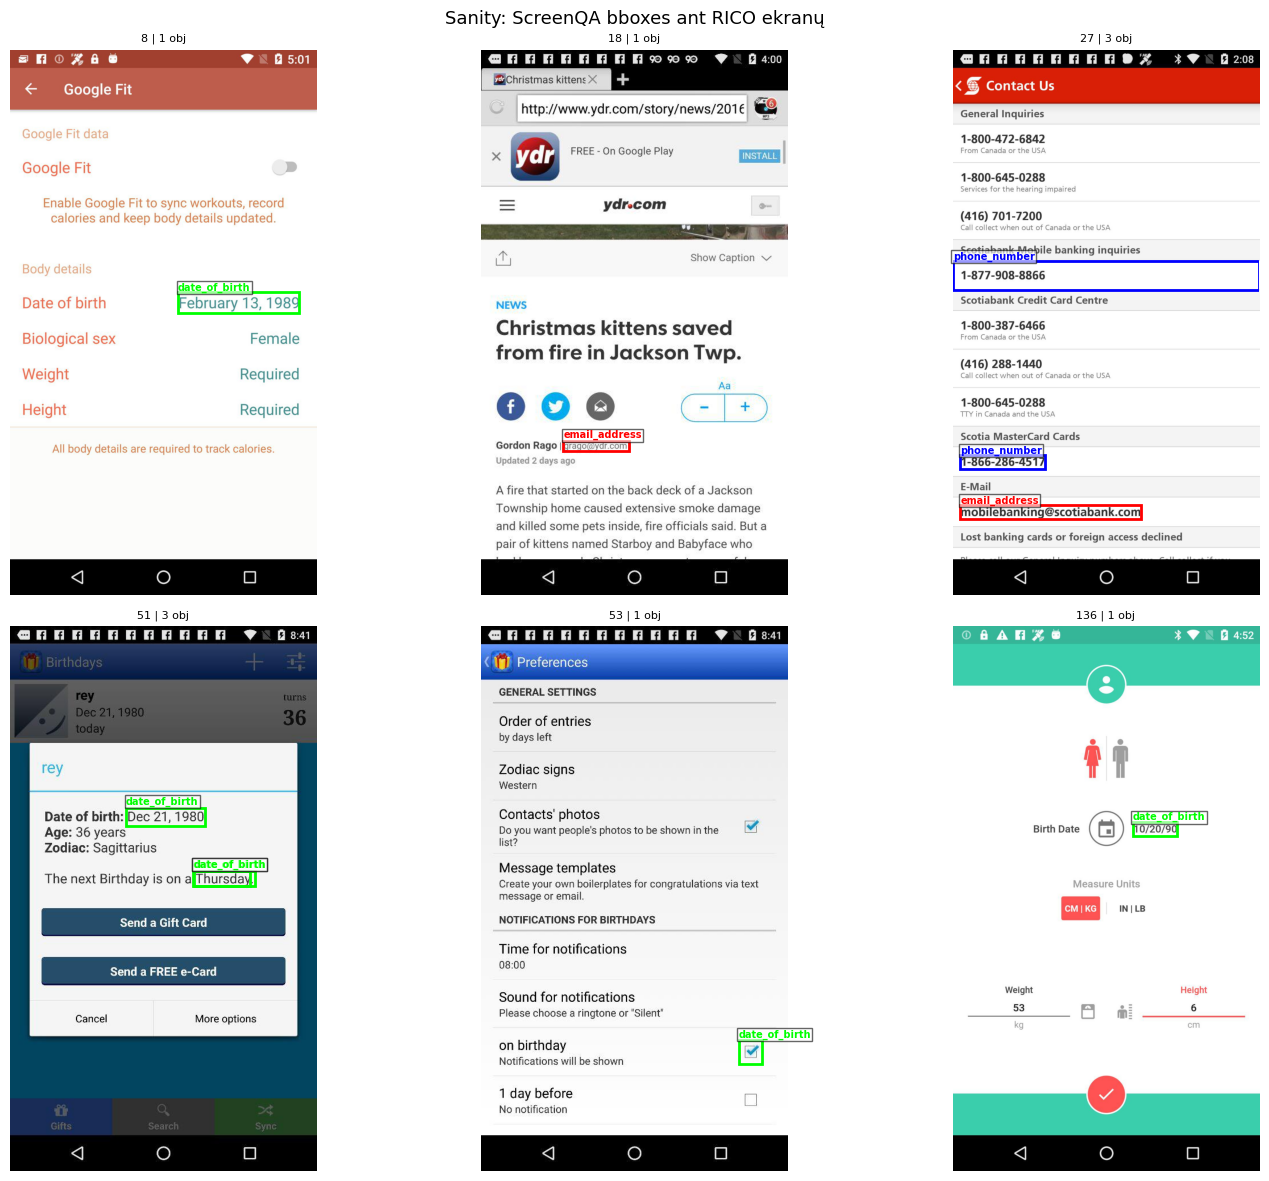

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# §7. VISUAL SANITY CHECK — draw bboxes on real screens
# ─────────────────────────────────────────────────────────────────────────────

COLORS = {
    "email_address": "red",    "phone_number": "blue",
    "full_name": "green",      "username": "orange",
    "account_balance": "purple", "transaction_amount": "brown",
    "account_number": "pink",  "address": "cyan",
    "date_of_birth": "lime",   "id_number": "magenta",
}

sample_sids = [e["screen_id"] for e in positive_entries if e["objects"]][:6]

if sample_sids:
    fig, axes = plt.subplots(2, 3, figsize=(15, 12))
    for ax, sid in zip(axes.flat, sample_sids):
        img_path = IMG_DIR / f"{sid}.png"
        if not img_path.exists():
            ax.set_title("not found"); ax.axis("off"); continue
        img = Image.open(img_path)
        ax.imshow(img)
        for obj in screen_data[sid]["objects"]:
            x1, y1, x2, y2 = obj["bbox"]
            color = COLORS.get(obj["label"], "red")
            ax.add_patch(patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=2, edgecolor=color, facecolor="none"
            ))
            ax.text(x1, max(y1 - 5, 0), obj["label"], color=color,
                    fontsize=7, fontweight="bold",
                    bbox=dict(facecolor="white", alpha=0.6, pad=1))
        ax.axis("off")
        ax.set_title(f"{sid} | {len(screen_data[sid][chr(39)]objects[chr(39)])} obj", fontsize=8)
        img.close()
    plt.suptitle("Sanity check: ScreenQA bboxes on RICO screens", fontsize=13)
    plt.tight_layout()
    plt.savefig(LOCAL_TMP / "eda_sanity_boxes.png", dpi=100)
    plt.show()
else:
    print("No PII screens found — check KEYWORD_MAP.")


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# §8. SAVE TO DRIVE
# ─────────────────────────────────────────────────────────────────────────────

def write_jsonl(path, entries):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        for e in entries:
            f.write(json.dumps(e, ensure_ascii=False) + "
")
    print(f"  {len(entries):,} lines -> {path}")

write_jsonl(OUT_DIR / "train.jsonl", train_entries)
write_jsonl(OUT_DIR / "val.jsonl",   val_entries)
write_jsonl(OUT_DIR / "test.jsonl",  test_entries)

# Copy images to Drive
out_img = OUT_DIR / "images"
out_img.mkdir(exist_ok=True)
needed  = {e["screen_id"] for e in final_entries}
copied  = 0
for sid in tqdm(needed, desc="Copying images to Drive"):
    src = IMG_DIR / f"{sid}.png"
    dst = out_img / f"{sid}.png"
    if src.exists() and not dst.exists():
        shutil.copy2(src, dst)
        copied += 1
print(f"Copied {copied:,} images")

# Create images.zip — M2 unpacks to local disk for faster training
zip_path = OUT_DIR / "images.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for f in tqdm(sorted(out_img.glob("*.png")), desc="Zipping"):
        zf.write(f, arcname=f"images/{f.name}")
print(f"images.zip = {zip_path.stat().st_size / 1024 ** 2:.0f} MB")

# Write README.md
readme = f"""# pii_v1 — Privacy Masker Dataset

**Author:** Member 1  |  **Schema:** v1.0

## Source
rootsautomation/RICO-ScreenQA (HuggingFace)
- screen_id, question, ground_truth[].ui_elements[].bounds, image — all in one place

## Filtering (SCHEMA §5)
- Regex on question text -> label (KEYWORD_MAP)
- Bboxes from ground_truth[].ui_elements[].bounds [left,top,right,bottom] XYXY float->int
- Union across all annotators, deduplicated by bbox+label
- Drop bboxes < {MIN_BBOX_PX}px in either dimension

## Statistics
| Split | Screens | PII objects | Empty screens |
|-------|---------|-------------|---------------|
| train | {len(train_entries)} | {sum(len(e[chr(39)]objects[chr(39)]) for e in train_entries)} | {sum(1 for e in train_entries if not e[chr(39)]objects[chr(39)])} |
| val   | {len(val_entries)} | {sum(len(e[chr(39)]objects[chr(39)]) for e in val_entries)} | {sum(1 for e in val_entries if not e[chr(39)]objects[chr(39)])} |
| test  | {len(test_entries)} | {sum(len(e[chr(39)]objects[chr(39)]) for e in test_entries)} | {sum(1 for e in test_entries if not e[chr(39)]objects[chr(39)])} |

## Label counts
{chr(10).join(f"- {l}: {c}" for l, c in sorted(Counter(all_labels).items(), key=lambda x: -x[1]))}

## Known issues
- Some RICO screens have aspect ratio mismatches.
- rootsautomation/RICO-ScreenQA uses validation as split name (not dev).
"""
with open(OUT_DIR / "README.md", "w") as f:
    f.write(readme)

# Copy EDA plots to Drive
eda_dir = OUT_DIR / "eda"
eda_dir.mkdir(exist_ok=True)
for png in LOCAL_TMP.glob("eda_*.png"):
    shutil.copy2(png, eda_dir / png.name)

print("
Dataset delivery complete!")
print(f"Location: {OUT_DIR}")


  2,916 eilučių -> /content/drive/MyDrive/VU_DL_Team_Project/data/pii_v1/train.jsonl
  364 eilučių -> /content/drive/MyDrive/VU_DL_Team_Project/data/pii_v1/val.jsonl
  365 eilučių -> /content/drive/MyDrive/VU_DL_Team_Project/data/pii_v1/test.jsonl


Copied 3,645 images


images.zip = 1471 MB

Dataset delivery complete!
Location: /content/drive/MyDrive/VU_DL_Team_Project/data/pii_v1


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# §9. INLINE VALIDATOR — run before handing over to M2
# ─────────────────────────────────────────────────────────────────────────────

VALID_LABELS = {
    "email_address", "phone_number", "full_name", "username",
    "account_balance", "transaction_amount", "account_number",
    "address", "date_of_birth", "profile_photo", "id_number", "other_sensitive"
}

def validate_dataset(data_dir, check_images=True):
    errors = []
    split_ids = {}
    for split in ["train", "val", "test"]:
        p = Path(data_dir) / f"{split}.jsonl"
        if not p.exists():
            errors.append(f"MISSING: {p}")
            continue
        ids = []
        for ln, line in enumerate(open(p, encoding="utf-8"), 1):
            line = line.strip()
            if not line:
                continue
            try:
                ex = json.loads(line)
            except Exception as e:
                errors.append(f"{split}:{ln} JSON err: {e}")
                continue
            # Check required fields
            for field in ["image", "image_width", "image_height", "screen_id", "objects"]:
                if field not in ex:
                    errors.append(f"{split}:{ln} missing field: {field}")
            iw = ex.get("image_width", 0)
            ih = ex.get("image_height", 0)
            ids.append(ex.get("screen_id", ""))
            # Check image file exists
            if check_images:
                ip = Path(data_dir) / ex.get("image", "")
                if not ip.exists():
                    errors.append(f"{split}:{ln} image not found: {ip.name}")
            # Validate each object
            for oi, obj in enumerate(ex.get("objects", [])):
                bb = obj.get("bbox")
                if not isinstance(bb, list) or len(bb) != 4:
                    errors.append(f"{split}:{ln} obj[{oi}] bbox must be list[4]")
                    continue
                x1, y1, x2, y2 = bb
                # Check XYXY constraints (SCHEMA §3)
                if not (0 <= x1 < x2 <= iw):
                    errors.append(f"{split}:{ln} obj[{oi}] x constraint failed {bb}")
                if not (0 <= y1 < y2 <= ih):
                    errors.append(f"{split}:{ln} obj[{oi}] y constraint failed {bb}")
                if x2 - x1 < 4 or y2 - y1 < 4:
                    errors.append(f"{split}:{ln} obj[{oi}] bbox too small")
                # Check label is in taxonomy
                if obj.get("label", "") not in VALID_LABELS:
                    errors.append(f"{split}:{ln} obj[{oi}] unknown label: {obj.get(chr(39)label{chr(39)}")}")
        split_ids[split] = set(ids)

    # Check for screen_id leakage between splits
    sp = list(split_ids.keys())
    for i in range(len(sp)):
        for j in range(i + 1, len(sp)):
            ov = split_ids[sp[i]] & split_ids[sp[j]]
            if ov:
                errors.append(f"LEAKAGE {sp[i]} and {sp[j]} share {len(ov)} screen_ids")
    return errors

print("Running validator...")
errs = validate_dataset(OUT_DIR, check_images=True)
if errs:
    print(f"ERRORS ({len(errs)}):")
    for e in errs[:50]:
        print(f"  - {e}")
    if len(errs) > 50:
        print(f"  ... and {len(errs)-50} more")
else:
    print("Validation OK — dataset ready for M2.")


Validuojam...
Validacija OK — dataset paruostas M2.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# §10. EDA — Label distribution per split
# ─────────────────────────────────────────────────────────────────────────────

split_map = {
    "train": train_entries,
    "val":   val_entries,
    "test":  test_entries,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (split_name, entries) in zip(axes, split_map.items()):
    labels = [obj["label"] for e in entries for obj in e["objects"]]
    lc = Counter(labels)
    n_empty = sum(1 for e in entries if not e["objects"])
    n_total = len(entries)

    ls = sorted(lc.keys(), key=lambda k: -lc[k])
    cl = ["steelblue" if l in PHASE1_LABELS else "lightcoral" for l in ls]
    bars = ax.bar(ls, [lc[l] for l in ls], color=cl, edgecolor="white")

    for bar, l in zip(bars, ls):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                str(lc[l]), ha="center", fontsize=8)

    ax.set_title(
        f"{split_name.upper()}  ({n_total} screens)
"
        f"Empty: {n_empty} ({n_empty/n_total*100:.1f}%)  |  "
        f"PII objects total: {sum(lc.values())}"
    )
    ax.set_xlabel("label")
    ax.set_ylabel("object count")
    plt.setp(ax.get_xticklabels(), rotation=40, ha="right", fontsize=8)

plt.suptitle("Label distribution per split", fontsize=14)
plt.tight_layout()
plt.savefig(LOCAL_TMP / "eda_per_split.png", dpi=120)
plt.show()

# Summary table
print(f"{'Label':<25s} {'Train':>8s} {'Val':>8s} {'Test':>8s}")
print("-" * 55)
all_ls = sorted(set(
    obj["label"]
    for entries in split_map.values()
    for e in entries
    for obj in e["objects"]
))
for l in all_ls:
    counts = {
        split: Counter(obj["label"] for e in entries for obj in e["objects"])[l]
        for split, entries in split_map.items()
    }
    p1p2 = "P1" if l in PHASE1_LABELS else "P2"
    print(f"{p1p2} {l:<23s} {counts[chr(39)train{chr(39)}]:>8d} {counts[chr(39)val{chr(39)}]:>8d} {counts[chr(39)test{chr(39)}]:>8d}")

print("-" * 55)
print(f"{'Total screens':<25s} "
      f"{len(train_entries):>8d} {len(val_entries):>8d} {len(test_entries):>8d}")
print(f"{'Empty screens':<25s} "
      f"{sum(1 for e in train_entries if not e[chr(39)objects{chr(39)}]):>8d} "
      f"{sum(1 for e in val_entries if not e[chr(39)objects{chr(39)}]):>8d} "
      f"{sum(1 for e in test_entries if not e[chr(39)objects{chr(39)}]):>8d}")


NameError: name 'train_entries' is not defined

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# §11. REMOVE RARE LABELS FROM SAVED JSONL
# Removes account_number and id_number — too few examples for model to learn
# Overwrites pii_v1 files in place
# ─────────────────────────────────────────────────────────────────────────────

import json
from pathlib import Path
from collections import Counter

DRIVE_ROOT = Path("/content/drive/MyDrive/VU_DL_Team_Project")
V1_DIR = DRIVE_ROOT / "data" / "pii_v1"
REMOVE_LABELS = {"account_number", "id_number"}

for split in ["train", "val", "test"]:
    path = V1_DIR / f"{split}.jsonl"
    entries = []

    # Read existing JSONL
    with open(path, encoding="utf-8") as f:
        for line in f:
            e = json.loads(line)
            # Filter out unwanted labels
            e["objects"] = [
                obj for obj in e["objects"]
                if obj["label"] not in REMOVE_LABELS
            ]
            entries.append(e)

    # Overwrite file in place
    with open(path, "w", encoding="utf-8") as f:
        for e in entries:
            f.write(json.dumps(e, ensure_ascii=False) + "
")

    # Print remaining label counts
    labels = Counter(obj["label"] for e in entries for obj in e["objects"])
    print(f"{split}: {len(entries):,} entries | labels: {dict(labels)}")

print("
Done.")


train: 2,916 entries | labels: {'username': 390, 'email_address': 1165, 'address': 472, 'account_balance': 114, 'date_of_birth': 201, 'phone_number': 537, 'full_name': 137, 'transaction_amount': 205}
val: 364 entries | labels: {'address': 78, 'email_address': 166, 'phone_number': 49, 'username': 52, 'full_name': 29, 'date_of_birth': 30, 'transaction_amount': 26, 'account_balance': 6}
test: 365 entries | labels: {'address': 53, 'phone_number': 60, 'date_of_birth': 31, 'full_name': 18, 'email_address': 152, 'transaction_amount': 38, 'username': 51, 'account_balance': 11}

Done.
